In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import cleaning_stephanie as cs
import seaborn as sns

In [140]:
Name_Soil_Temp = "Brocket_AGDM.csv"
Name_Soil_Mois= "Brocket AGDM.csv"

#Manning AGDM

## Soil Temp

In [141]:
df_Soil_Temp_AGDM=pd.read_csv(Name_Soil_Temp)
df_Soil_Temp_AGDM.head()

,time,soil_temp_deg_C_at_5_cm_depth,soil_temp_deg_C_at_20_cm_depth,soil_temp_deg_C_at_50_cm_depth,soil_temp_deg_C_at_100_cm_depth
0,2005-05-01 00:00:00,5.9,6.5,6.4,6.0
1,2005-05-01 01:00:00,5.6,6.5,6.4,6.0
2,2005-05-01 02:00:00,5.4,6.4,6.4,6.0
3,2005-05-01 03:00:00,5.1,6.4,6.3,6.0
4,2005-05-01 04:00:00,4.9,6.4,6.3,6.0


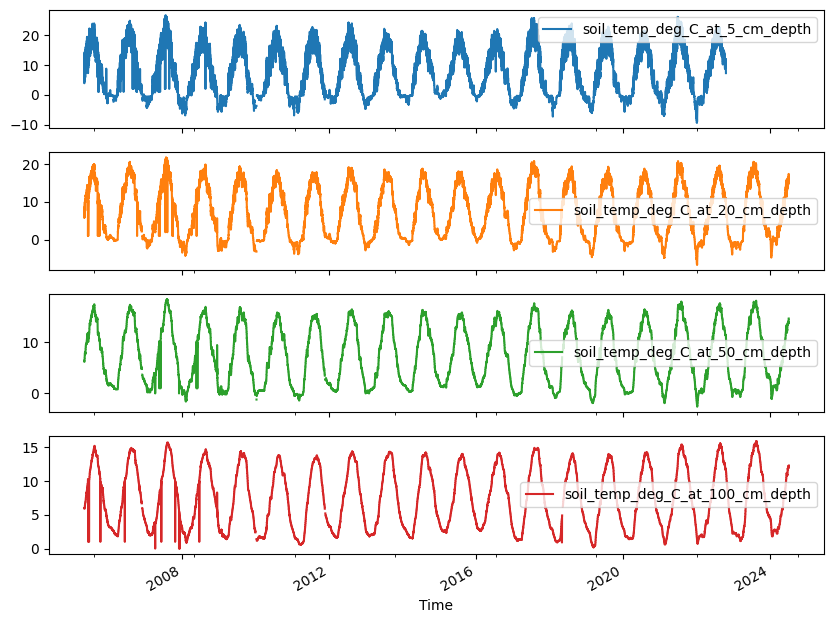

In [142]:
df_Soil_Temp_AGDM["time"] = pd.to_datetime(df_Soil_Temp_AGDM["time"])
df_Soil_Temp_AGDM = df_Soil_Temp_AGDM.set_index("time")

variables = df_Soil_Temp_AGDM.columns.values

df_Soil_Temp_AGDM[variables].plot(subplots=True, figsize=(10, 8), sharex=True)

plt.xlabel("Time")
plt.show()

In [143]:
df_Soil_Temp_AGDM.mean()

,0
soil_temp_deg_C_at_5_cm_depth,7.426440
soil_temp_deg_C_at_20_cm_depth,7.225547
soil_temp_deg_C_at_50_cm_depth,7.395448
soil_temp_deg_C_at_100_cm_depth,7.450703


In [144]:
df_Soil_Temp_AGDM.max()

,0
soil_temp_deg_C_at_5_cm_depth,26.7
soil_temp_deg_C_at_20_cm_depth,21.8
soil_temp_deg_C_at_50_cm_depth,18.5
soil_temp_deg_C_at_100_cm_depth,15.9


In [145]:
df_Soil_Temp_AGDM.min()

,0
soil_temp_deg_C_at_5_cm_depth,-9.4
soil_temp_deg_C_at_20_cm_depth,-6.6
soil_temp_deg_C_at_50_cm_depth,-2.6
soil_temp_deg_C_at_100_cm_depth,0.0


In [146]:
NaN_Original=df_Soil_Temp_AGDM.isna().sum()
NaN_Original

,0
soil_temp_deg_C_at_5_cm_depth,27899
soil_temp_deg_C_at_20_cm_depth,12906
soil_temp_deg_C_at_50_cm_depth,12905
soil_temp_deg_C_at_100_cm_depth,12906


In [147]:
df_Soil_Temp_AGDM.notna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,151828
soil_temp_deg_C_at_20_cm_depth,166821
soil_temp_deg_C_at_50_cm_depth,166822
soil_temp_deg_C_at_100_cm_depth,166821


# Specific TH Stuck
In this method we remove any set of repeated values larger than  `sens_stuck `. This method is better for the model fitting part.

##Neighborhood Outliers

This proposal eliminates an entire neighborhood of size `segment_th` surrounding any value considered an outlier. This is because, when using the returns approach, the first point might be an outlier with respect to the previous normal trend, but subsequent points will be normal with respect to the outlier. However, only the first detected outlier will be eliminated, as subsequent returns would be normal with respect to the removed outlier.

The current method looks for outliers with a positive or negative jump and searches the surroundings for an opposite jump that adjusts to the normal value without counting intermediate NaN values ​​that might be present to remove the section completely.

###Returns Removed Using Percentils
An outlier is considered to be any return that is above the `up` percentile or below the `low` percentile.


In [148]:
from cleaning_stephanie import soil_temp_percentil_neighborhood_outliers

Text(0.5, 0, 'Time')

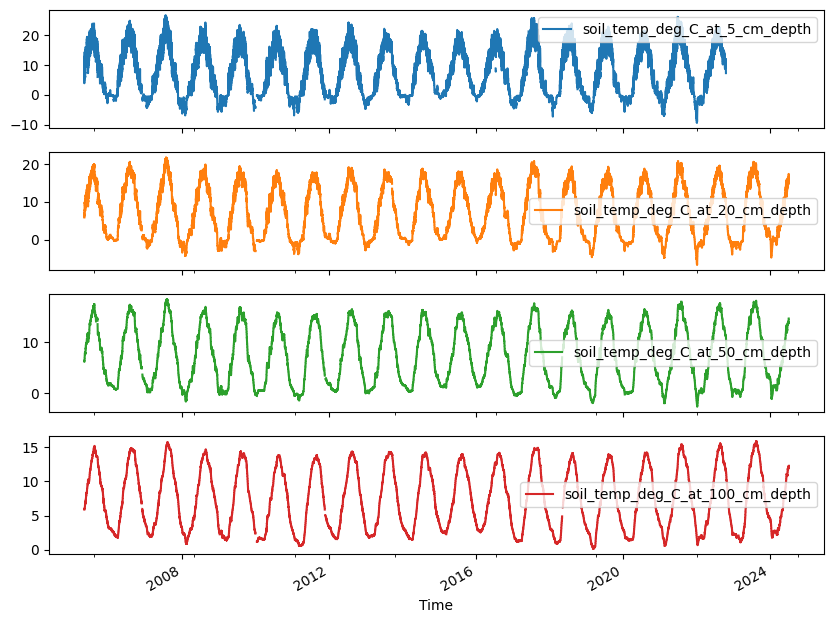

In [149]:
df_Clean_per,returns_per_clean=soil_temp_percentil_neighborhood_outliers(df=df_Soil_Temp_AGDM,low=0.00001,up=0.99999,th_returns=200,sens_stuck=50,segment_th = 2)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")

In [150]:
df_Clean_per.to_csv("Champion_AGDM_temperature_cleaned.csv")

In [151]:
df_Clean_per.max()

,0
soil_temp_deg_C_at_5_cm_depth,26.7
soil_temp_deg_C_at_20_cm_depth,21.8
soil_temp_deg_C_at_50_cm_depth,18.5
soil_temp_deg_C_at_100_cm_depth,15.9


In [152]:
df_Clean_per.min()

,0
soil_temp_deg_C_at_5_cm_depth,-9.4
soil_temp_deg_C_at_20_cm_depth,-6.6
soil_temp_deg_C_at_50_cm_depth,-2.6
soil_temp_deg_C_at_100_cm_depth,0.2


In [153]:
df_Clean_per.notna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,143124
soil_temp_deg_C_at_20_cm_depth,151628
soil_temp_deg_C_at_50_cm_depth,142491
soil_temp_deg_C_at_100_cm_depth,124929


In [154]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_temp_deg_C_at_5_cm_depth,36603
soil_temp_deg_C_at_20_cm_depth,28099
soil_temp_deg_C_at_50_cm_depth,37236
soil_temp_deg_C_at_100_cm_depth,54798


In [155]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_temp_deg_C_at_5_cm_depth,8704
soil_temp_deg_C_at_20_cm_depth,15193
soil_temp_deg_C_at_50_cm_depth,24331
soil_temp_deg_C_at_100_cm_depth,41892


In [156]:
df_Clean_per

,soil_temp_deg_C_at_5_cm_depth,soil_temp_deg_C_at_20_cm_depth,soil_temp_deg_C_at_50_cm_depth,soil_temp_deg_C_at_100_cm_depth
time,,,,
2005-05-01 00:00:00,NaN,NaN,NaN,NaN
2005-05-01 01:00:00,NaN,NaN,NaN,NaN
2005-05-01 02:00:00,5.4,6.4,6.4,6.0
2005-05-01 03:00:00,5.1,6.4,6.3,6.0
2005-05-01 04:00:00,4.9,6.4,6.3,6.0
...,...,...,...,...
2025-10-31 19:00:00,NaN,NaN,NaN,NaN
2025-10-31 20:00:00,NaN,NaN,NaN,NaN
2025-10-31 21:00:00,NaN,NaN,NaN,NaN


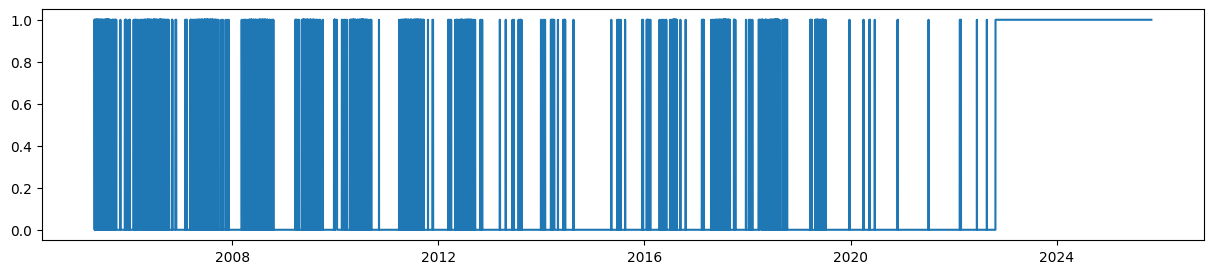

In [157]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,3))
plt.plot(df_Clean_per['soil_temp_deg_C_at_5_cm_depth'].isna())
plt.show()

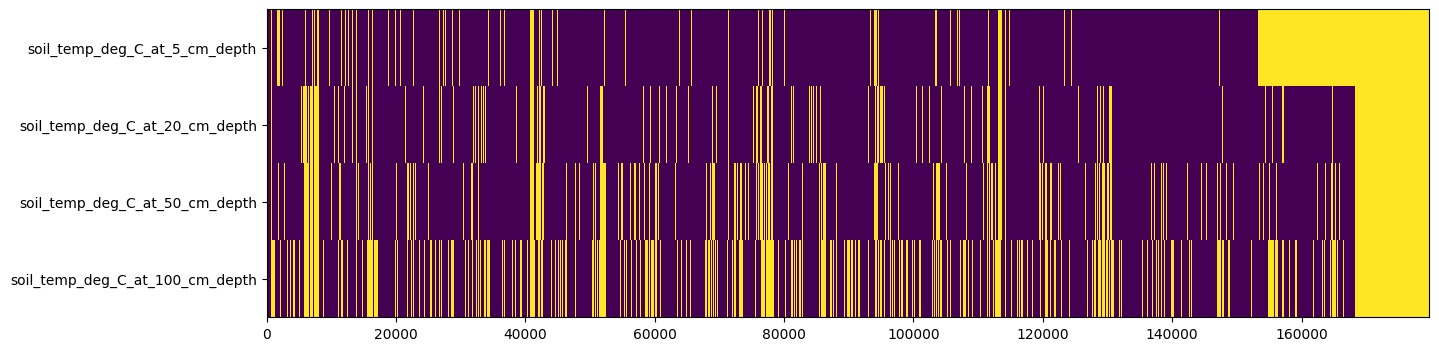

In [158]:
plt.figure(figsize=(15,4))
plt.imshow(
    df_Clean_per.isna().T,
    aspect='auto',
    interpolation='nearest'
)
plt.yticks(range(len(df_Clean_per.columns)), df_Clean_per.columns)
plt.show()

In [159]:
df_Clean_per.shape


(179727, 4)

In [160]:
df_Clean_per.isna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,36603
soil_temp_deg_C_at_20_cm_depth,28099
soil_temp_deg_C_at_50_cm_depth,37236
soil_temp_deg_C_at_100_cm_depth,54798


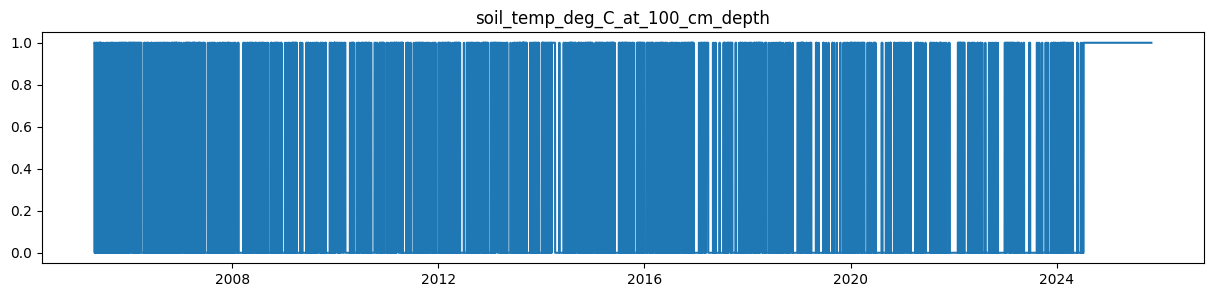

In [161]:
col = 'soil_temp_deg_C_at_100_cm_depth'

plt.figure(figsize=(15,3))
plt.plot(df_Clean_per[col].isna().astype(int))
plt.title(col)
plt.show()

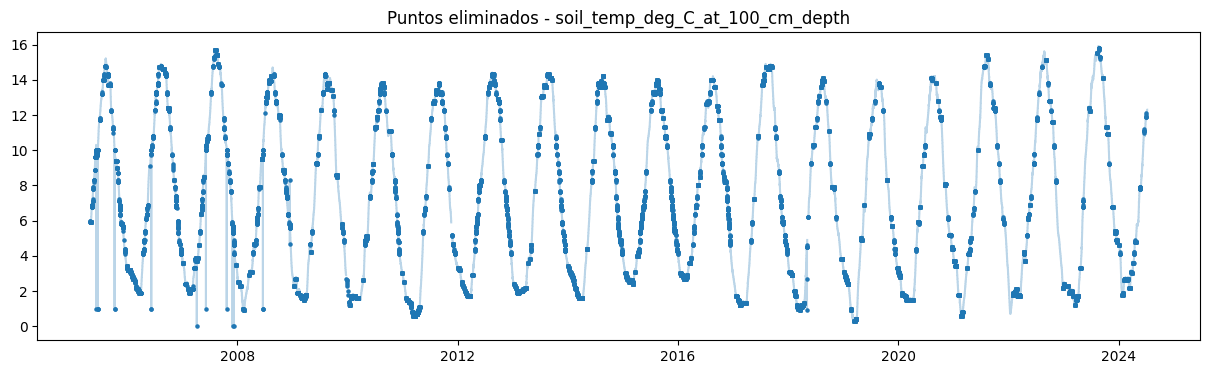

In [162]:
col = 'soil_temp_deg_C_at_100_cm_depth'

# puntos que fueron eliminados en el limpio
bad_mask = df_Clean_per[col].isna()

plt.figure(figsize=(15,4))

# serie original completa
plt.plot(df_Soil_Temp_AGDM.index,
         df_Soil_Temp_AGDM[col],
         alpha=0.3)

# puntos eliminados resaltados
plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
            df_Soil_Temp_AGDM.loc[bad_mask, col],
            s=5)

plt.title(f'Puntos eliminados - {col}')
plt.show()

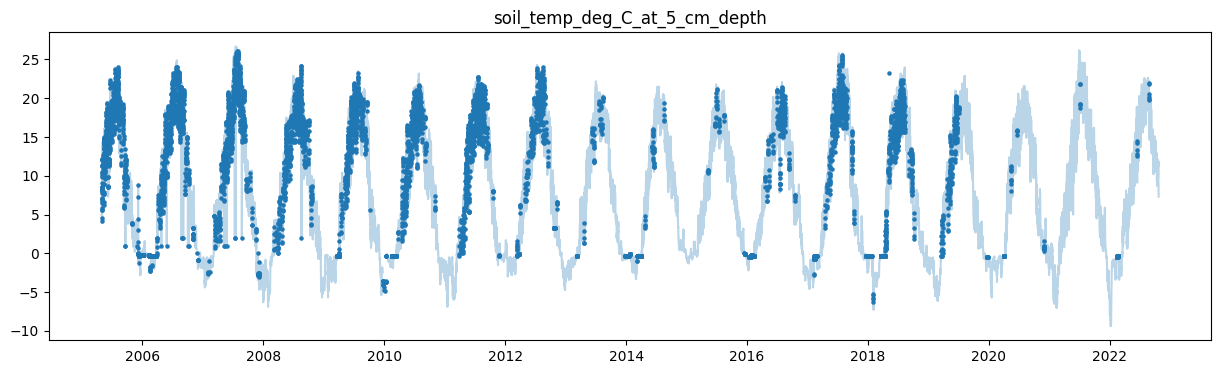

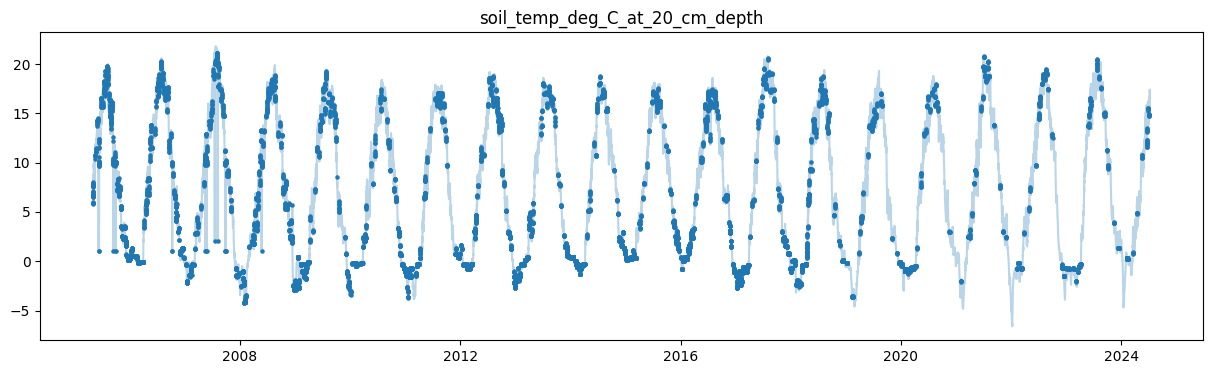

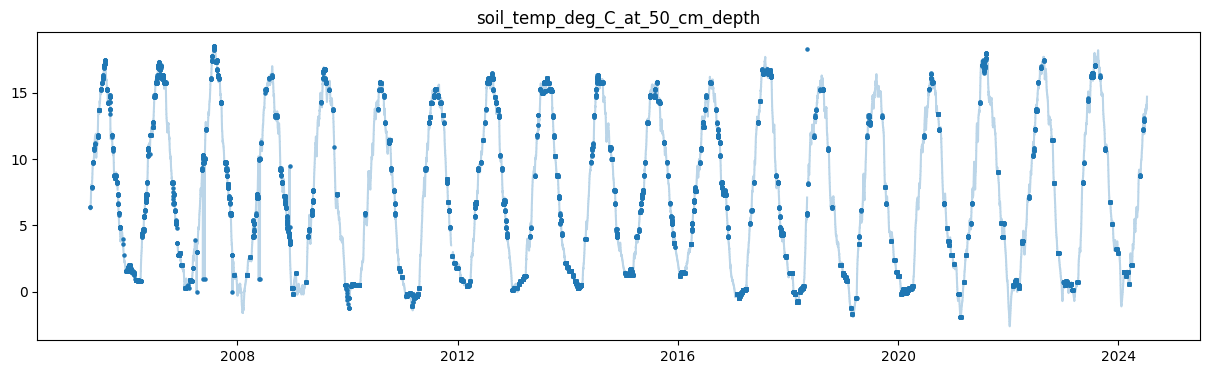

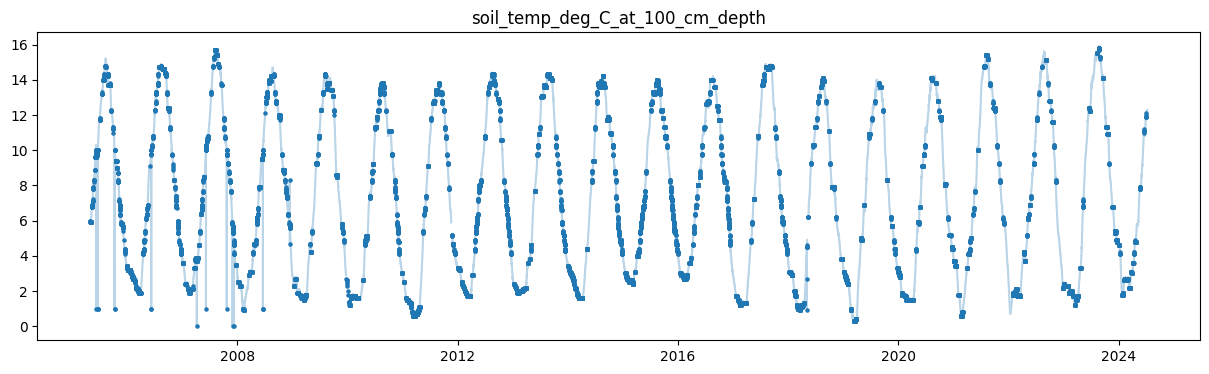

In [163]:
for col in df_Soil_Temp_AGDM.columns:

    bad_mask = (
    df_Clean_per[col].isna()
    & df_Soil_Temp_AGDM[col].notna()
    )

    plt.figure(figsize=(15,4))

    plt.plot(df_Soil_Temp_AGDM.index,
             df_Soil_Temp_AGDM[col],
             alpha=0.3)

    plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
                df_Soil_Temp_AGDM.loc[bad_mask, col],
                s=5)

    plt.title(col)
    plt.show()

In [164]:
df_Clean_per.isna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,36603
soil_temp_deg_C_at_20_cm_depth,28099
soil_temp_deg_C_at_50_cm_depth,37236
soil_temp_deg_C_at_100_cm_depth,54798


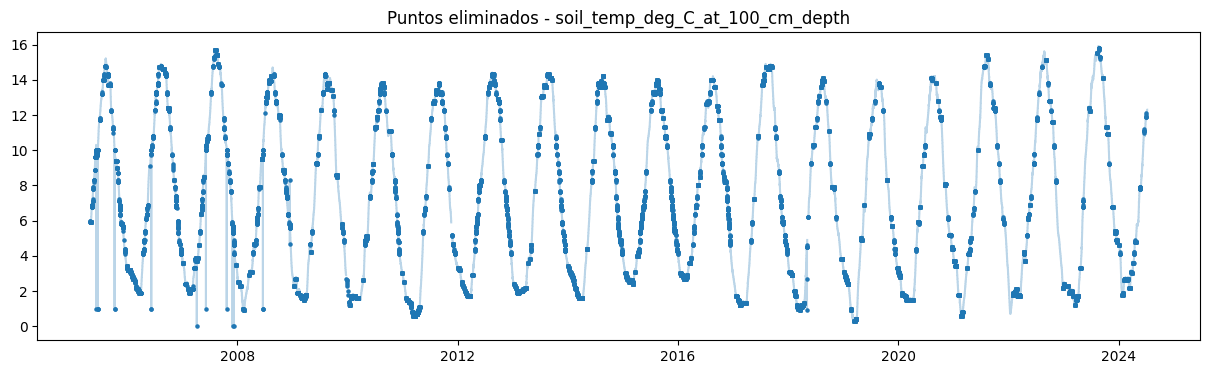

In [165]:
col = 'soil_temp_deg_C_at_100_cm_depth'

# puntos que fueron eliminados en el limpio
bad_mask = df_Clean_per[col].isna()

plt.figure(figsize=(15,4))

# serie original completa
plt.plot(df_Soil_Temp_AGDM.index,
         df_Soil_Temp_AGDM[col],
         alpha=0.3)

# puntos eliminados resaltados
plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
            df_Soil_Temp_AGDM.loc[bad_mask, col],
            s=5)

plt.title(f'Puntos eliminados - {col}')
plt.show()

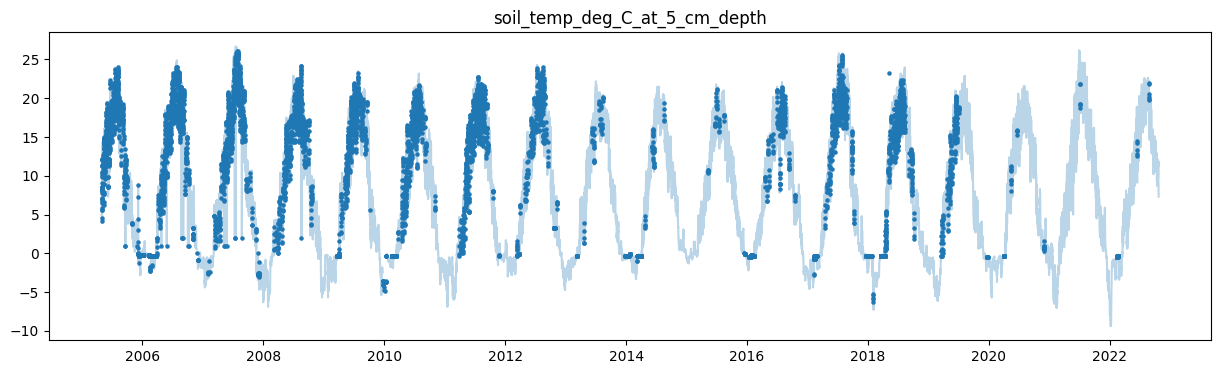

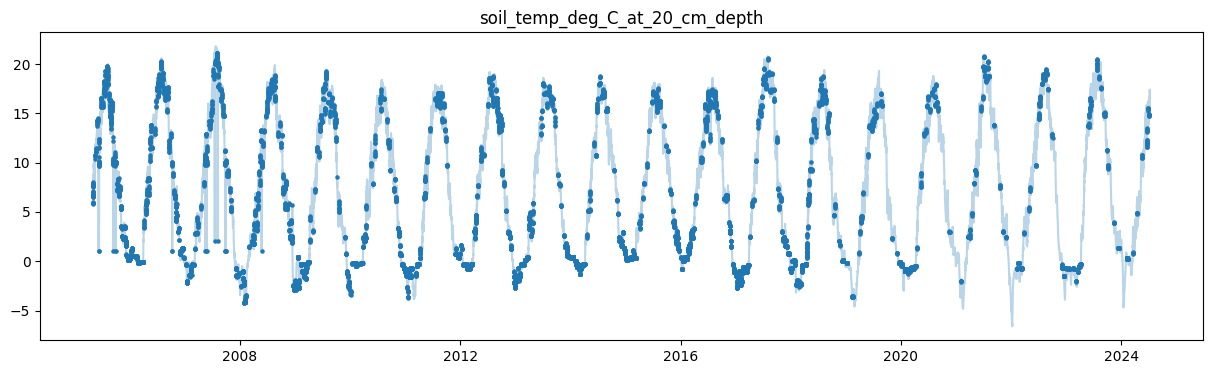

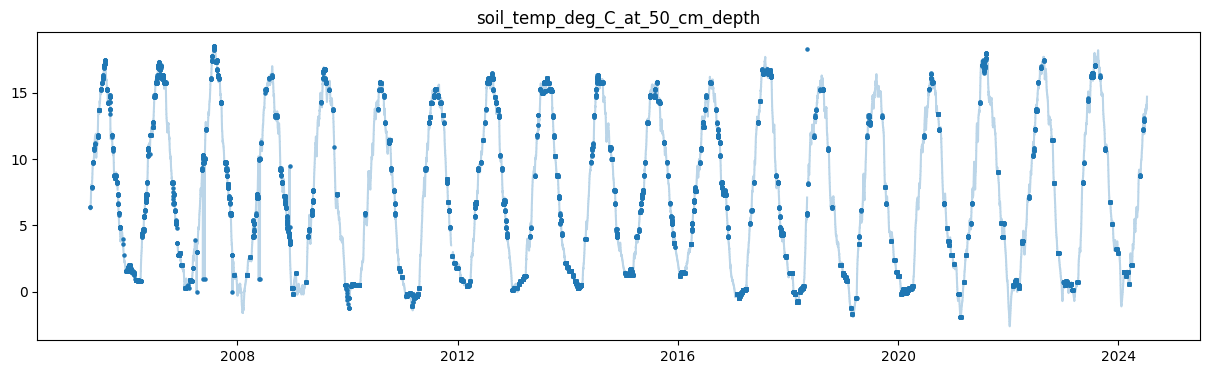

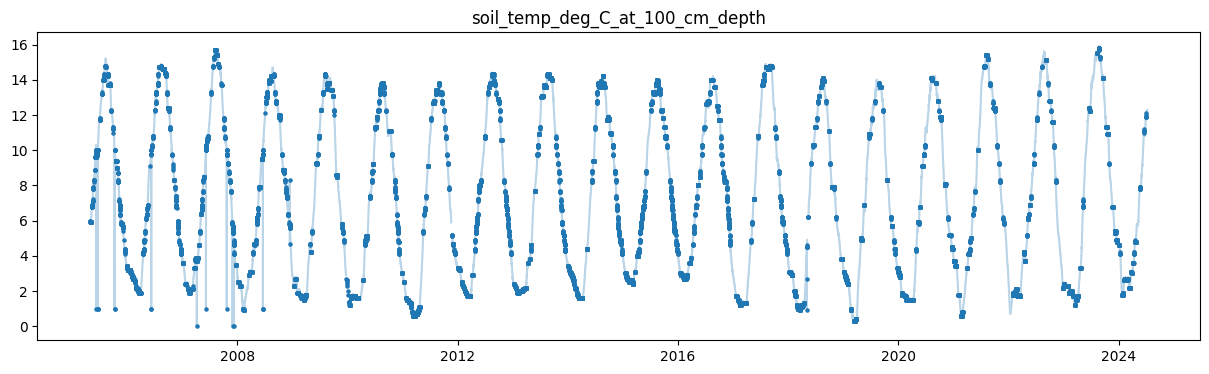

In [166]:
for col in df_Soil_Temp_AGDM.columns:

    bad_mask = (
    df_Clean_per[col].isna()
    & df_Soil_Temp_AGDM[col].notna()
    )

    plt.figure(figsize=(15,4))

    plt.plot(df_Soil_Temp_AGDM.index,
             df_Soil_Temp_AGDM[col],
             alpha=0.3)

    plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
                df_Soil_Temp_AGDM.loc[bad_mask, col],
                s=5)

    plt.title(col)
    plt.show()

# Z Scores Not Used


In [167]:
from cleaning_stephanie import soil_temp_zscores_neighborhood_outliers

Text(0.5, 0, 'Time')

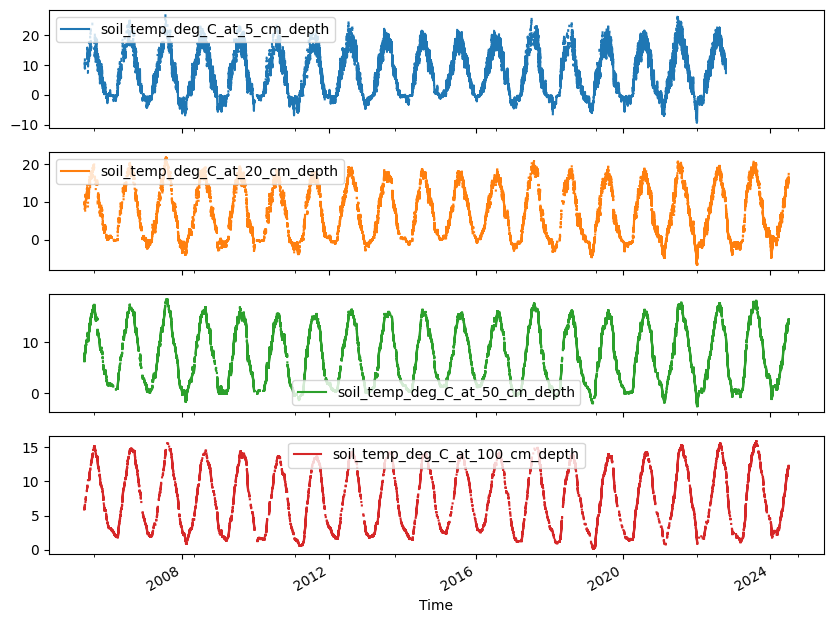

In [168]:
df_Clean_per,returns_per_clean=soil_temp_zscores_neighborhood_outliers(df=df_Soil_Temp_AGDM,zscr_sd=3,th_returns=2,sens_stuck=20,segment_th = 20)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [169]:
df_Clean_per.max()

,0
soil_temp_deg_C_at_5_cm_depth,26.7
soil_temp_deg_C_at_20_cm_depth,21.8
soil_temp_deg_C_at_50_cm_depth,18.5
soil_temp_deg_C_at_100_cm_depth,15.9


In [170]:
df_Clean_per.min()

,0
soil_temp_deg_C_at_5_cm_depth,-9.4
soil_temp_deg_C_at_20_cm_depth,-6.6
soil_temp_deg_C_at_50_cm_depth,-2.6
soil_temp_deg_C_at_100_cm_depth,0.2


In [171]:
df_Clean_per.notna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,100180
soil_temp_deg_C_at_20_cm_depth,65493
soil_temp_deg_C_at_50_cm_depth,76986
soil_temp_deg_C_at_100_cm_depth,53436


In [172]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_temp_deg_C_at_5_cm_depth,79547
soil_temp_deg_C_at_20_cm_depth,114234
soil_temp_deg_C_at_50_cm_depth,102741
soil_temp_deg_C_at_100_cm_depth,126291


In [173]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_temp_deg_C_at_5_cm_depth,51648
soil_temp_deg_C_at_20_cm_depth,101328
soil_temp_deg_C_at_50_cm_depth,89836
soil_temp_deg_C_at_100_cm_depth,113385


# Moisture

In [174]:
df_Soil_Temp_AGDM=pd.read_csv(Name_Soil_Mois)
df_Soil_Temp_AGDM.head()

,time,soil_moisture_percent_at_5_cm_depth,soil_moisture_percent_at_20_cm_depth,soil_moisture_percent_at_50_cm_depth,soil_moisture_percent_at_100_cm_depth
0,2005-05-01 00:00:00,16.6,29.8,34.5,38.8
1,2005-05-01 01:00:00,16.6,29.8,34.5,38.8
2,2005-05-01 02:00:00,16.6,29.8,34.5,38.8
3,2005-05-01 03:00:00,16.5,29.8,34.5,38.8
4,2005-05-01 04:00:00,16.5,29.8,34.5,38.8


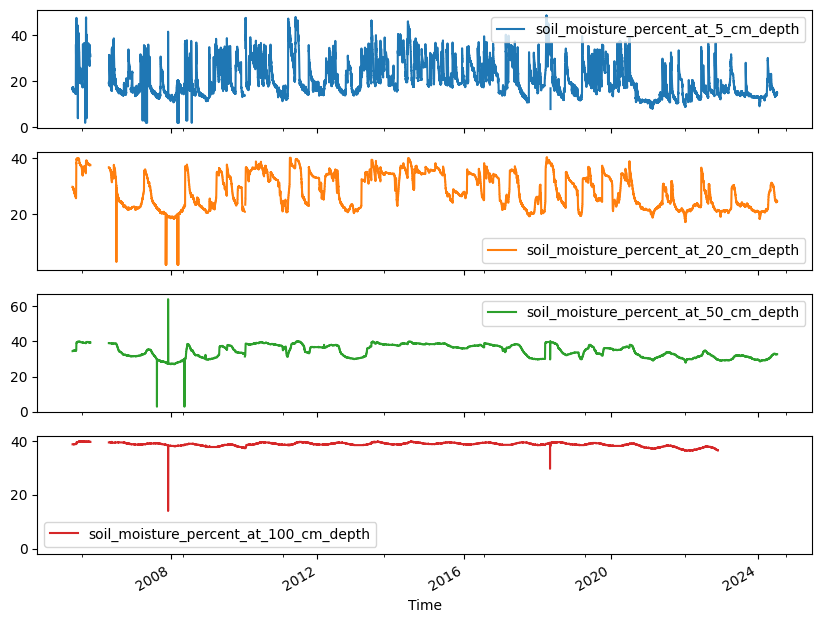

In [175]:
df_Soil_Temp_AGDM["time"] = pd.to_datetime(df_Soil_Temp_AGDM["time"])
df_Soil_Temp_AGDM = df_Soil_Temp_AGDM.set_index("time")

variables = df_Soil_Temp_AGDM.columns.values

df_Soil_Temp_AGDM[variables].plot(subplots=True, figsize=(10, 8), sharex=True)

plt.xlabel("Time")
plt.show()

In [176]:
df_Soil_Temp_AGDM.mean()

,0
soil_moisture_percent_at_5_cm_depth,20.859298
soil_moisture_percent_at_20_cm_depth,28.383179
soil_moisture_percent_at_50_cm_depth,34.603136
soil_moisture_percent_at_100_cm_depth,38.747972


In [177]:
df_Soil_Temp_AGDM.max()

,0
soil_moisture_percent_at_5_cm_depth,48.7
soil_moisture_percent_at_20_cm_depth,40.3
soil_moisture_percent_at_50_cm_depth,64.0
soil_moisture_percent_at_100_cm_depth,40.0


In [178]:
df_Soil_Temp_AGDM.min()

,0
soil_moisture_percent_at_5_cm_depth,2.0
soil_moisture_percent_at_20_cm_depth,2.0
soil_moisture_percent_at_50_cm_depth,3.0
soil_moisture_percent_at_100_cm_depth,0.0


In [179]:
NaN_Original=df_Soil_Temp_AGDM.isna().sum()
NaN_Original

,0
soil_moisture_percent_at_5_cm_depth,17231
soil_moisture_percent_at_20_cm_depth,17219
soil_moisture_percent_at_50_cm_depth,17220
soil_moisture_percent_at_100_cm_depth,31268


In [180]:
df_Soil_Temp_AGDM.notna().sum()

,0
soil_moisture_percent_at_5_cm_depth,162496
soil_moisture_percent_at_20_cm_depth,162508
soil_moisture_percent_at_50_cm_depth,162507
soil_moisture_percent_at_100_cm_depth,148459


###Returns Removed Using Percentils
An outlier is considered to be any return that is above the `up` percentile or below the `low` percentile.

Text(0.5, 0, 'Time')

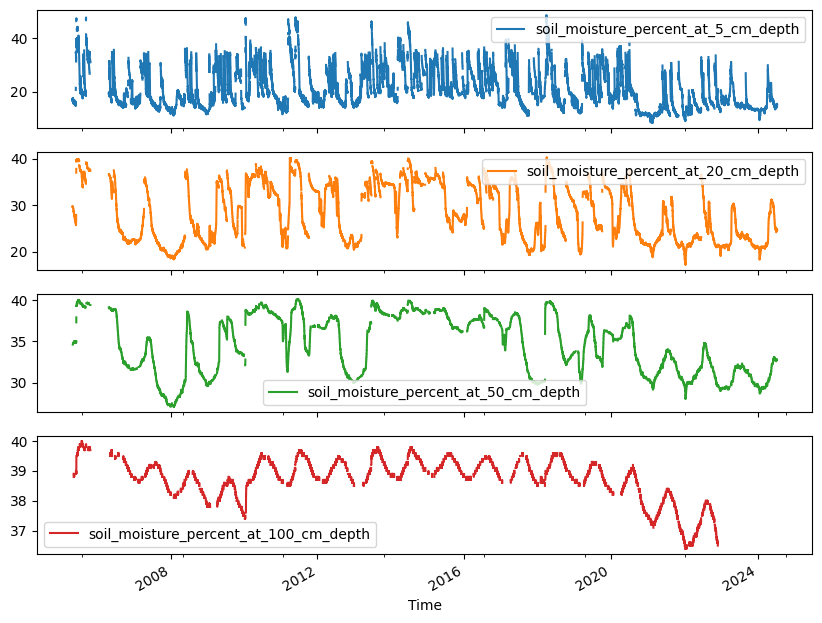

In [181]:
df_Clean_per,returns_per_clean=soil_temp_percentil_neighborhood_outliers(df=df_Soil_Temp_AGDM,low=0.00001,up=0.99999,th_returns=200,sens_stuck=50,segment_th = 2)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [182]:
df_Clean_per.max()

,0
soil_moisture_percent_at_5_cm_depth,48.7
soil_moisture_percent_at_20_cm_depth,40.3
soil_moisture_percent_at_50_cm_depth,40.1
soil_moisture_percent_at_100_cm_depth,40.0


In [183]:
df_Clean_per.min()

,0
soil_moisture_percent_at_5_cm_depth,8.2
soil_moisture_percent_at_20_cm_depth,17.2
soil_moisture_percent_at_50_cm_depth,27.1
soil_moisture_percent_at_100_cm_depth,36.4


In [184]:
df_Clean_per.notna().sum()

,0
soil_moisture_percent_at_5_cm_depth,157614
soil_moisture_percent_at_20_cm_depth,136728
soil_moisture_percent_at_50_cm_depth,55954
soil_moisture_percent_at_100_cm_depth,36518


In [185]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_moisture_percent_at_5_cm_depth,22113
soil_moisture_percent_at_20_cm_depth,42999
soil_moisture_percent_at_50_cm_depth,123773
soil_moisture_percent_at_100_cm_depth,143209


In [186]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_moisture_percent_at_5_cm_depth,4882
soil_moisture_percent_at_20_cm_depth,25780
soil_moisture_percent_at_50_cm_depth,106553
soil_moisture_percent_at_100_cm_depth,111941


# Z Scores Not Used


In [187]:
from cleaning_stephanie import soil_temp_zscores_neighborhood_outliers

Text(0.5, 0, 'Time')

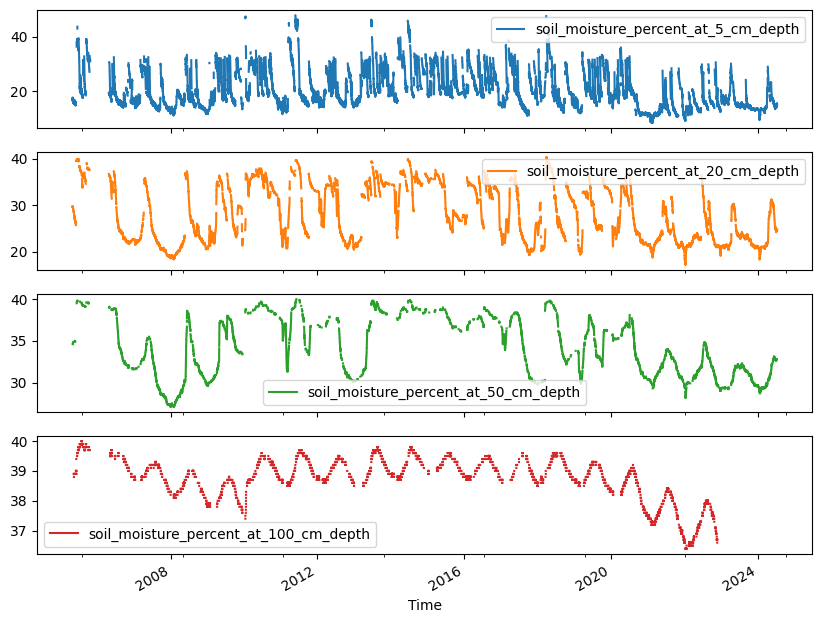

In [188]:
df_Clean_per,returns_per_clean=soil_temp_zscores_neighborhood_outliers(df=df_Soil_Temp_AGDM,zscr_sd=3,th_returns=2,sens_stuck=20,segment_th = 20)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [189]:
df_Clean_per.max()

,0
soil_moisture_percent_at_5_cm_depth,48.0
soil_moisture_percent_at_20_cm_depth,40.3
soil_moisture_percent_at_50_cm_depth,40.0
soil_moisture_percent_at_100_cm_depth,40.0


In [190]:
df_Clean_per.min()

,0
soil_moisture_percent_at_5_cm_depth,8.2
soil_moisture_percent_at_20_cm_depth,17.2
soil_moisture_percent_at_50_cm_depth,27.1
soil_moisture_percent_at_100_cm_depth,36.4


In [191]:
df_Clean_per.notna().sum()

,0
soil_moisture_percent_at_5_cm_depth,139990
soil_moisture_percent_at_20_cm_depth,86560
soil_moisture_percent_at_50_cm_depth,17287
soil_moisture_percent_at_100_cm_depth,23850


In [192]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_moisture_percent_at_5_cm_depth,39737
soil_moisture_percent_at_20_cm_depth,93167
soil_moisture_percent_at_50_cm_depth,162440
soil_moisture_percent_at_100_cm_depth,155877


In [193]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_moisture_percent_at_5_cm_depth,22506
soil_moisture_percent_at_20_cm_depth,75948
soil_moisture_percent_at_50_cm_depth,145220
soil_moisture_percent_at_100_cm_depth,124609
